In [9]:
import tkinter as tk
from tkinter import filedialog, ttk, messagebox
import os
import io
import time
import matplotlib.pyplot as plt
from matplotlib.widgets import SpanSelector
from scipy import stats
from scipy.optimize import curve_fit
import pandas as pd
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import numpy as np

## Model class
Defines every FCS correlation model (3D/2D, 1 or 2 diffusing populations, with/without a triplet term) and knows how to fit itself to a tau/G(tau) curve via `curve_fit`.

**New in this version:** any parameter can be fixed (not just N/K/DC), and fitting can be restricted to a sub-range of tau.

In [10]:
plt.rcParams['agg.path.chunksize'] = 10000

# ---------------------------------------------------------------------------
# Parameter bookkeeping shared between the Model (fitting) and the GUI.
# ---------------------------------------------------------------------------

# Full ordered parameter list for every model type. Anything not in this list
# for a given model type is simply not applicable to that model.
PARAM_NAMES = {
    "3D_1p":    ["N", "tau_D", "K", "DC"],
    "3D_2p":    ["N", "F2", "tau_D", "tau_D2", "K", "DC"],
    "3D_1p1t":  ["N", "tau_D", "K", "F_T", "tau_T", "DC"],
    "3D_2p1t":  ["N", "F2", "tau_D", "tau_D2", "K", "F_T", "tau_T", "DC"],
    "2D_1p":    ["N", "tau_D", "DC"],
    "2D_2p":    ["N", "F2", "tau_D", "tau_D2", "DC"],
    "2D_1p1t":  ["N", "tau_D", "F_T", "tau_T", "DC"],
    "2D_2p1t":  ["N", "F2", "tau_D", "tau_D2", "F_T", "tau_T", "DC"],
}

# Union of every parameter across every model - this is the fixed row list
# shown in the GUI (rows for parameters not used by the current model are
# simply grayed out).
ALL_PARAMS = ["N", "F2", "tau_D", "tau_D2", "K", "F_T", "tau_T", "DC"]

DEFAULT_GUESS = {
    "N": 10, "tau_D": 0.1, "tau_D2": 1.0, "F2": 0.5,
    "K": 5, "F_T": 0.1, "tau_T": 0.001, "DC": 0
}


class Model:
    """
    Holds one tau/G(tau) curve plus a chosen FCS model, and knows how to
    fit it via scipy.optimize.curve_fit.

    fixed_params: dict like {"K": 5.0, "DC": 0.0}. Any parameter named here
    is held fixed at that value during the fit; everything else in the
    model's parameter list is fit freely. Keys that don't belong to the
    chosen model type are ignored (harmless if the GUI sends extra values).

    fit_range: optional (tau_min, tau_max) tuple. Either side may be None
    to mean "no limit". Only points inside this range are used for the
    actual curve_fit call; the full data is still returned/plotted.
    """

    def __init__(self, x, y, model_type, fixed_params=None, fit_range=None):
        x = np.asarray(x, dtype=float)
        y = np.asarray(y, dtype=float)
        mask = x > 0
        self.x_full = x[mask]
        self.y_full = y[mask]
        self.type = model_type
        self.fixed_params = {k: v for k, v in (fixed_params or {}).items() if v is not None}
        self.fit_range = fit_range
        self.params_final = {}
        self.popt = None
        self.pcov = None
        self._wrapper = None

    # ---------- 3D MODELS ----------
    def fcs_3D_1p(self, tau, N, tau_D, K, DC):
        return (
            (1 / N)
            * (1 + tau / tau_D) ** (-1)
            * (1 + tau / (tau_D * K ** 2)) ** (-0.5)
            + DC
        )

    def fcs_3D_2p(self, tau, N, F2, tau_D, tau_D2, K, DC):
        comp1 = (
            (1 - F2)
            * (1 + tau / tau_D) ** (-1)
            * (1 + tau / (tau_D * K ** 2)) ** (-0.5)
        )
        comp2 = (
            F2
            * (1 + tau / tau_D2) ** (-1)
            * (1 + tau / (tau_D2 * K ** 2)) ** (-0.5)
        )
        return (1 / N) * (comp1 + comp2) + DC

    def fcs_3D_1p1t(self, tau, N, tau_D, K, F_T, tau_T, DC):
        diffusion = (
            (1 + tau / tau_D) ** (-1)
            * (1 + tau / (tau_D * K ** 2)) ** (-0.5)
        )
        triplet = 1 + (F_T / (1 - F_T)) * np.exp(-tau / tau_T)
        return (1 / N) * diffusion * triplet + DC

    def fcs_3D_2p1t(self, tau, N, F2, tau_D, tau_D2, K, F_T, tau_T, DC):
        comp1 = (
            (1 - F2)
            * (1 + tau / tau_D) ** (-1)
            * (1 + tau / (tau_D * K ** 2)) ** (-0.5)
        )
        comp2 = (
            F2
            * (1 + tau / tau_D2) ** (-1)
            * (1 + tau / (tau_D2 * K ** 2)) ** (-0.5)
        )
        triplet = 1 + (F_T / (1 - F_T)) * np.exp(-tau / tau_T)
        return (1 / N) * (comp1 + comp2) * triplet + DC

    # ---------- 2D MODELS ----------
    def fcs_2D_1p(self, tau, N, tau_D, DC):
        return (1 / N) * (1 + tau / tau_D) ** (-1) + DC

    def fcs_2D_2p(self, tau, N, F2, tau_D, tau_D2, DC):
        comp1 = (1 - F2) * (1 + tau / tau_D) ** (-1)
        comp2 = F2 * (1 + tau / tau_D2) ** (-1)
        return (1 / N) * (comp1 + comp2) + DC

    def fcs_2D_1p1t(self, tau, N, tau_D, F_T, tau_T, DC):
        diffusion = (1 + tau / tau_D) ** (-1)
        triplet = 1 + (F_T / (1 - F_T)) * np.exp(-tau / tau_T)
        return (1 / N) * diffusion * triplet + DC

    def fcs_2D_2p1t(self, tau, N, F2, tau_D, tau_D2, F_T, tau_T, DC):
        comp1 = (1 - F2) * (1 + tau / tau_D) ** (-1)
        comp2 = F2 * (1 + tau / tau_D2) ** (-1)
        triplet = 1 + (F_T / (1 - F_T)) * np.exp(-tau / tau_T)
        return (1 / N) * (comp1 + comp2) * triplet + DC

    def _fit_mask(self):
        x = self.x_full
        mask = np.ones_like(x, dtype=bool)
        if self.fit_range:
            tmin, tmax = self.fit_range
            if tmin is not None:
                mask &= x >= tmin
            if tmax is not None:
                mask &= x <= tmax
        return mask

    def fit(self):
        """Run curve_fit and store the result in self.params_final."""
        all_params = PARAM_NAMES[self.type]
        fixed = {p: v for p, v in self.fixed_params.items() if p in all_params}
        fit_params = [p for p in all_params if p not in fixed]

        func = getattr(self, f"fcs_{self.type}")

        def wrapper(tau, *free_params):
            d = dict(fixed)
            d.update(zip(fit_params, free_params))
            ordered = [d[p] for p in all_params]
            return func(tau, *ordered)

        mask = self._fit_mask()
        x_fit = self.x_full[mask]
        y_fit = self.y_full[mask]

        if len(x_fit) < max(3, len(fit_params) + 1):
            raise ValueError(
                f"Not enough data points ({len(x_fit)}) in the selected "
                f"fit range for {len(fit_params)} free parameters."
            )

        if fit_params:
            p0 = [DEFAULT_GUESS[p] for p in fit_params]
            popt, pcov = curve_fit(wrapper, x_fit, y_fit, p0=p0, maxfev=20000)
        else:
            # every parameter is fixed - nothing to fit, just evaluate
            popt, pcov = np.array([]), np.zeros((0, 0))

        result = dict(fixed)
        result.update(zip(fit_params, popt))

        self.params_final = result
        self.popt = popt
        self.pcov = pcov
        self._wrapper = wrapper
        return result

    def plot(self, ax_main=None, ax_res=None):
        if not self.params_final:
            self.fit()

        if ax_main is None or ax_res is None:
            fig, (ax_main, ax_res) = plt.subplots(2, 1, sharex=True)

        ax_main.set_xscale("log")
        ax_res.set_xscale("log")

        # shade the part(s) of the data that were excluded from the fit
        if self.fit_range:
            tmin, tmax = self.fit_range
            data_min, data_max = self.x_full.min(), self.x_full.max()
            if tmin is not None and tmin > data_min:
                ax_main.axvspan(data_min, tmin, color="gray", alpha=0.15, lw=0)
            if tmax is not None and tmax < data_max:
                ax_main.axvspan(tmax, data_max, color="gray", alpha=0.15, lw=0)

        x_curve = np.logspace(
            np.log10(self.x_full.min()), np.log10(self.x_full.max()), 1000
        )
        y_curve = self._wrapper(x_curve, *self.popt)

        ax_main.scatter(self.x_full, self.y_full, s=10, color="blue", alpha=0.5,
                         label="Experimental Data")
        ax_main.plot(self.x_full, self.y_full, color="blue", alpha=0.3, lw=0.7)
        ax_main.plot(x_curve, y_curve, "r-", label="Fit")

        mask = self._fit_mask()
        x_res = self.x_full[mask]
        y_pred = self._wrapper(x_res, *self.popt)
        residuals = self.y_full[mask] - y_pred
        ax_res.plot(x_res, residuals)
        ax_res.axhline(0, color="gray", lw=0.7)

        ax_main.legend()


# ---------------------------------------------------------------------------
# A single tau/G(tau) curve as it appears in the file list. One loaded file
# can produce several Datasets (several columns in a .dat file, or several
# spots in a .czi file) - these are always kept separate, never averaged
# together, since they are physically distinct measurements.
# ---------------------------------------------------------------------------

## Dataset + DataAnalysisApp (the GUI)
`Dataset` is one tau/G(tau) curve (one block of a `.dat` file, one spot of a `.czi` file, or one `.ptu` file). `DataAnalysisApp` is the Tkinter window that lists datasets, lets you fix/free parameters, restrict the fit range, and compute mean/std across a multi-selection of datasets.

In [11]:
class Dataset:
    def __init__(self, label, tau, g, intensity=None, source_file=None):
        self.label = label
        self.tau = np.asarray(tau, dtype=float)
        self.g = np.asarray(g, dtype=float)
        self.intensity = intensity
        self.source_file = source_file
        self.error = None  # optional per-point uncertainty column, if present
        # populated after a fit is run, mainly for the stats tool
        self.fit_result = None
        self.model_type = None


class DataAnalysisApp:
    def __init__(self, root):
        self.root = root
        self.root.title("FCS FITTING APP")
        self.root.geometry("1450x800")

        self.datasets = []          # list[Dataset]
        self.loaded_files = set()   # paths already loaded, to avoid duplicates
        self.current_dataset = None

        self.param_entries = {}         # param name -> Entry (fix value)
        self.param_result_labels = {}   # param name -> Label (fit result)

        self.setup_ui()

    # ================= UI =================
    def setup_ui(self):

        # -------- SIDEBARS --------
        self.sidebar = tk.Frame(self.root, width=260, bg="#f0f0f0",
                                 relief="sunken", borderwidth=1)
        self.sidebar.pack(side="left", fill="y")

        self.sidebar2 = tk.Frame(self.root, width=320, bg="#f0f0f0",
                                  relief="sunken", borderwidth=1)
        self.sidebar2.pack(side="right", fill="y")

        self.main_content = tk.Frame(self.root, bg="white")
        self.main_content.pack(side="right", expand=True, fill="both")

        # -------- FILES --------
        tk.Label(self.sidebar, text="File Explorer",
                 font=("Arial", 12, "bold"), bg="#f0f0f0").pack(pady=10)

        btn_frame = tk.Frame(self.sidebar, bg="#f0f0f0")
        btn_frame.pack(fill="x", padx=5)

        tk.Button(btn_frame, text="Load Files",
                  command=self.load_files).pack(side="left", fill="x", expand=True)

        tk.Button(btn_frame, text="Load Folder",
                  command=self.load_folder).pack(side="left", fill="x", expand=True)

        tk.Label(self.sidebar,
                 text="Each row below is one dataset\n"
                      "(a .dat column or a .czi spot).\n"
                      "Ctrl/Shift-click to multi-select.",
                 justify="left", bg="#f0f0f0", fg="gray30",
                 font=("Arial", 8)).pack(fill="x", padx=5, pady=(0, 5))

        self.file_listbox = tk.Listbox(self.sidebar, selectmode=tk.EXTENDED)
        self.file_listbox.pack(expand=True, fill="both", padx=5, pady=5)
        self.file_listbox.bind("<<ListboxSelect>>", self.on_file_select)
        self.file_listbox.bind("<Delete>", lambda e: self.remove_selected())
        self.file_listbox.bind("<BackSpace>", lambda e: self.remove_selected())

        tk.Button(self.sidebar, text="Remove Selected",
                  command=self.remove_selected).pack(fill="x", padx=5, pady=(0, 5))

        tk.Button(self.sidebar, text="Compute Stats for Selected",
                  command=self.compute_stats).pack(fill="x", padx=5, pady=(0, 10))

        # -------- CONTROLS --------
        self.controls = tk.Frame(self.main_content, height=90,
                                  relief="raised", borderwidth=1)
        self.controls.pack(fill="x")

        tk.Label(self.controls, text="Model:").grid(row=0, column=0, padx=(5, 2), pady=5)

        self.fit_style = ttk.Combobox(
            self.controls,
            state="readonly",
            values=list(PARAM_NAMES.keys()),
            width=10,
        )
        self.fit_style.set("3D_1p")
        self.fit_style.grid(row=0, column=1, pady=5)
        self.fit_style.bind("<<ComboboxSelected>>", self.on_model_change)

        tk.Button(self.controls, text="Update Fit",
                  command=self.update_graphs).grid(row=0, column=2, padx=10)

        tk.Label(self.controls, text="Fit range (tau):").grid(row=0, column=3, padx=(20, 2))
        self.fit_min_entry = tk.Entry(self.controls, width=10)
        self.fit_min_entry.grid(row=0, column=4)
        tk.Label(self.controls, text="to").grid(row=0, column=5, padx=3)
        self.fit_max_entry = tk.Entry(self.controls, width=10)
        self.fit_max_entry.grid(row=0, column=6)

        tk.Button(self.controls, text="Clear Range",
                  command=self.clear_fit_range).grid(row=0, column=7, padx=10)

        tk.Label(self.controls,
                 text="(or drag across the top plot to select a range)",
                 fg="gray30", font=("Arial", 8)).grid(row=1, column=0, columnspan=8,
                                                        sticky="w", padx=5)

        # -------- PARAM / RESULTS SIDEBAR (combined) --------
        tk.Label(self.sidebar2, text="Model & Parameters",
                 font=("Arial", 12, "bold"), bg="#f0f0f0").pack(pady=(10, 0))

        self.model_name_label = tk.Label(
            self.sidebar2, text="Model: -", font=("Arial", 10, "italic"),
            bg="#f0f0f0", fg="gray20"
        )
        self.model_name_label.pack(pady=(0, 10))

        param_frame = tk.Frame(self.sidebar2, bg="#f0f0f0")
        param_frame.pack(padx=8)

        tk.Label(param_frame, text="Parameter", bg="#f0f0f0",
                 font=("Arial", 9, "bold")).grid(row=0, column=0, sticky="w")
        tk.Label(param_frame, text="Fix to", bg="#f0f0f0",
                 font=("Arial", 9, "bold")).grid(row=0, column=1)
        tk.Label(param_frame, text="Result", bg="#f0f0f0",
                 font=("Arial", 9, "bold")).grid(row=0, column=2, sticky="w")

        for i, p in enumerate(ALL_PARAMS, start=1):
            tk.Label(param_frame, text=p, bg="#f0f0f0", anchor="w",
                     width=8).grid(row=i, column=0, sticky="w", pady=1)

            entry = tk.Entry(param_frame, width=8)
            entry.grid(row=i, column=1, padx=4, pady=1)
            self.param_entries[p] = entry

            result_label = tk.Label(param_frame, text="-", bg="#f0f0f0",
                                     anchor="w", width=12)
            result_label.grid(row=i, column=2, sticky="w", pady=1)
            self.param_result_labels[p] = result_label

        tk.Label(self.sidebar2,
                 text="Blank = fit freely.\nA value = hold fixed.\n"
                      "Grayed out = not used by\nthe current model.",
                 justify="left", bg="#f0f0f0", fg="gray30",
                 font=("Arial", 8)).pack(pady=(8, 4))

        self.update_param_panel_relevance()

        # -------- PLOTS --------
        self.fig = plt.figure(figsize=(10, 6), constrained_layout=True)
        gs = self.fig.add_gridspec(2, 2)

        self.ax_main = self.fig.add_subplot(gs[0, :])
        self.ax_int = self.fig.add_subplot(gs[1, 0])
        self.ax_res = self.fig.add_subplot(gs[1, 1])

        self.canvas = FigureCanvasTkAgg(self.fig, master=self.main_content)
        self.canvas.get_tk_widget().pack(expand=True, fill="both")

        # interactive fit-range selection: drag across the main plot
        self.span_selector = SpanSelector(
            self.ax_main,
            self.on_span_select,
            "horizontal",
            useblit=True,
            props=dict(alpha=0.2, facecolor="tab:orange"),
            interactive=True,
        )

    # ================= MODEL / PARAM PANEL =================
    def on_model_change(self, event=None):
        self.update_param_panel_relevance()

    def update_param_panel_relevance(self):
        """Gray out rows that don't apply to the currently chosen model,
        and keep the model name label in sync."""
        model_type = self.fit_style.get()
        self.model_name_label.config(text=f"Model: {model_type}")

        active_params = PARAM_NAMES.get(model_type, [])
        for p, entry in self.param_entries.items():
            if p in active_params:
                entry.config(state="normal", bg="white")
            else:
                entry.delete(0, tk.END)
                entry.config(state="disabled", bg="#dddddd")

    def get_fixed_params(self):
        """Read the 'Fix to' column for whichever params are enabled for the
        current model. Blank -> not fixed (fit freely)."""
        model_type = self.fit_style.get()
        active_params = PARAM_NAMES.get(model_type, [])
        fixed = {}
        for p in active_params:
            entry = self.param_entries[p]
            val = entry.get().strip()
            if val == "":
                continue
            try:
                fixed[p] = float(val)
            except ValueError:
                messagebox.showwarning(
                    "Invalid value",
                    f"Could not parse '{val}' for parameter {p}. "
                    f"That parameter will be fit freely instead."
                )
        return fixed

    def get_fit_range(self):
        def parse(entry):
            v = entry.get().strip()
            if v == "":
                return None
            try:
                return float(v)
            except ValueError:
                messagebox.showwarning("Invalid value",
                                        f"Could not parse fit-range value '{v}'.")
                return None
        tmin = parse(self.fit_min_entry)
        tmax = parse(self.fit_max_entry)
        if tmin is None and tmax is None:
            return None
        return (tmin, tmax)

    def clear_fit_range(self):
        self.fit_min_entry.delete(0, tk.END)
        self.fit_max_entry.delete(0, tk.END)
        self.update_graphs()

    def on_span_select(self, tmin, tmax):
        self.fit_min_entry.delete(0, tk.END)
        self.fit_min_entry.insert(0, f"{tmin:.4g}")
        self.fit_max_entry.delete(0, tk.END)
        self.fit_max_entry.insert(0, f"{tmax:.4g}")
        self.update_graphs()

    def update_result_labels(self, params_final, fixed_params):
        for p in ALL_PARAMS:
            label = self.param_result_labels[p]
            if p in params_final:
                label.config(text=f"{params_final[p]:.4g}",
                             fg=("gray40" if p in fixed_params else "black"))
            else:
                label.config(text="-", fg="gray60")

    # ================= FILES =================
    def load_files(self):
        files = filedialog.askopenfilenames(
            filetypes=[("Data", "*.dat *.czi *.ptu")]
        )
        for f in files:
            self._load_one_file(f)

    def load_folder(self):
        folder = filedialog.askdirectory()
        if not folder:
            return
        for r, _, fs in os.walk(folder):
            for f in fs:
                if f.lower().endswith((".dat", ".czi", ".ptu")):
                    self._load_one_file(os.path.join(r, f))

    def _load_one_file(self, path):
        if path in self.loaded_files:
            return
        try:
            if path.lower().endswith(".dat"):
                new_datasets = self.dat_to_datasets(path)
            elif path.lower().endswith(".czi"):
                new_datasets = self.czi_to_datasets(path, downsample=50)
            elif path.lower().endswith(".ptu"):
                new_datasets = self.ptu_to_datasets(path)
            else:
                return
        except Exception as exc:
            messagebox.showerror("Failed to load file",
                                  f"Could not load {os.path.basename(path)}:\n{exc}")
            return

        if not new_datasets:
            return

        self.loaded_files.add(path)
        for ds in new_datasets:
            self.datasets.append(ds)
            self.file_listbox.insert(tk.END, ds.label)

    @staticmethod
    def _is_data_row(line):
        """A line counts as a numeric data row if its first two
        whitespace-separated tokens both parse as floats."""
        parts = line.split()
        if len(parts) < 2:
            return False
        try:
            float(parts[0])
            float(parts[1])
            return True
        except ValueError:
            return False

    def dat_to_datasets(self, path):
        """Real correlator .dat files look like:

            wnt3wls_561_5.ptu                     <- optional title/comment line(s)
            Correlation_time_ms    G_t    Err     <- header row
            0.0000024   0.8665891   0
            ...

        and, in principle, several such [header + data] blocks could be
        stacked back to back in one file for multiple datasets. Rather than
        assume the header is always on a fixed line number, this scans for
        the header dynamically: it's whatever line is itself NOT numeric
        data but is immediately followed by a line that IS - that skips any
        leading title/comment line(s) automatically. If that header line
        repeats later in the file, each repeat starts a new dataset;
        otherwise the whole file is treated as one dataset.

        Column 0 is tau, column 1 is G(tau), and an optional column 2 is a
        per-point error/uncertainty (kept on the Dataset for reference, not
        treated as its own dataset)."""
        with open(path, "r") as f:
            lines = [line for line in f.readlines() if line.strip() != ""]
        if not lines:
            raise ValueError("File is empty.")

        header_idx = None
        for i, line in enumerate(lines[:-1]):
            if not self._is_data_row(line) and self._is_data_row(lines[i + 1]):
                header_idx = i
                break
        if header_idx is None:
            raise ValueError(
                "Could not find a header row followed by numeric data in this file."
            )

        header_tokens = lines[header_idx].split()
        block_starts = [i for i, line in enumerate(lines) if line.split() == header_tokens]
        block_starts.append(len(lines))

        fname = os.path.basename(path)
        multi = (len(block_starts) - 1) > 1
        datasets = []

        for b in range(len(block_starts) - 1):
            start, end = block_starts[b] + 1, block_starts[b + 1]
            block_lines = [line for line in lines[start:end] if self._is_data_row(line)]
            if not block_lines:
                continue

            block_df = pd.read_csv(io.StringIO("".join(block_lines)), sep=r"\s+", header=None)
            if block_df.shape[1] < 2:
                continue

            tau = pd.to_numeric(block_df.iloc[:, 0]).values
            g = pd.to_numeric(block_df.iloc[:, 1]).values

            label = f"{fname} [dataset {b + 1}]" if multi else fname
            ds = Dataset(label, tau, g, source_file=path)
            if block_df.shape[1] >= 3:
                ds.error = pd.to_numeric(block_df.iloc[:, 2]).values
            datasets.append(ds)

        if not datasets:
            raise ValueError("No data rows found after the header row(s).")
        return datasets

    def czi_to_df(self, filepath, frame_time=1.2e-6, skip_points=10, downsample=1):
        from multipletau import autocorrelate
        from aicspylibczi import CziFile
        start_time = time.perf_counter()

        czi = CziFile(filepath)
        full_img, dims = czi.read_image()

        dim_names = []
        for dim in dims:
            dim_names.append(dim[0] if isinstance(dim, tuple) else dim)

        if "S" in dim_names:
            s_index = dim_names.index("S")
            s_dim = full_img.shape[s_index]
        else:
            s_index = None
            s_dim = 1

        results = []

        for s in range(s_dim):

            if s_index is not None:
                indexer = [slice(None)] * full_img.ndim
                indexer[s_index] = s
                spot_img = full_img[tuple(indexer)]
            else:
                spot_img = full_img

            detectors = np.moveaxis(spot_img, 0, 0)
            detectors_flat = detectors.reshape(detectors.shape[0], -1)

            if downsample > 1:
                n = (detectors_flat.shape[1] // downsample) * downsample
                detectors_flat = detectors_flat[:, :n]
                detectors_flat = detectors_flat.reshape(
                    detectors_flat.shape[0], -1, downsample
                ).mean(axis=2)

            intensity = np.mean(detectors_flat[:19], axis=0)
            time_ax = np.arange(len(intensity)) * frame_time * downsample

            intensity_df = pd.DataFrame({"time": time_ax, "intensity": intensity})

            gtau = [
                autocorrelate(
                    a=detectors_flat[i],
                    deltat=frame_time * downsample,
                    normalize=True,
                    m=10,
                )
                for i in range(19)
            ]

            tau = gtau[0][skip_points:, 0]
            g_vals = [g[skip_points:, 1] for g in gtau]
            g = np.mean(np.stack(g_vals), axis=0)

            tau_g_df = pd.DataFrame({"tau": tau, "g": g})

            results.append({
                "spot": s,
                "intensity_df": intensity_df,
                "tau_g_df": tau_g_df,
            })

        execution_time = time.perf_counter() - start_time
        print(f"Function took {execution_time:.4f} seconds to run.")
        return results

    def czi_to_datasets(self, path, downsample=50):
        """Every spot in a .czi file is its own physical measurement -
        keep each one as a separate Dataset rather than averaging across
        spots (averaging across the 19 detector channels *within* a spot
        is still done in czi_to_df, which is a different and legitimate
        kind of averaging)."""
        results = self.czi_to_df(path, downsample=downsample)
        fname = os.path.basename(path)
        datasets = []
        for r in results:
            label = f"{fname} [spot {r['spot']}]"
            tau = r["tau_g_df"]["tau"].values
            g = r["tau_g_df"]["g"].values
            intensity = r["intensity_df"]["intensity"].values
            datasets.append(Dataset(label, tau, g, intensity=intensity, source_file=path))
        return datasets

    def ptu_to_datasets(self, path, bin_width=1e-3, skip_points=10):
        """Reads a PicoQuant .ptu photon-timestamp file: bins photons per
        detector channel into an intensity trace, autocorrelates each
        channel, then averages the first 19 channels together into one
        tau/G(tau) curve - the same "average detectors within one physical
        measurement" pattern used for .czi files. A .ptu file has no notion
        of multiple spots, so this always returns exactly one Dataset."""
        from ptufile import PtuFile
        from multipletau import autocorrelate

        ptu = PtuFile(path)
        try:
            decoded = ptu.decode_records()
            times = decoded["time"]
            channels = decoded["channel"]

            time_resolution = ptu.global_resolution
            times_s = times * time_resolution

            t_max = times_s.max()
            bins = np.arange(0, t_max, bin_width)

            n_detectors = int(channels.max()) + 1

            ffp1d = []
            for d in range(n_detectors):
                mask = channels == d
                counts, _ = np.histogram(times_s[mask], bins=bins)
                ffp1d.append(counts)

            mean_intensity = np.mean(ffp1d, axis=0)

            gtau_all = [
                autocorrelate(
                    a=ffp1d[d].astype(np.float64),
                    deltat=bin_width,
                    normalize=True,
                    m=10,
                )
                for d in range(n_detectors)
            ]

            inner_data = [gtau[skip_points:, 1] for gtau in gtau_all[:19]]
            tau = gtau_all[0][skip_points:, 0]
            mean_acf = np.mean(np.stack(inner_data), axis=0)
        finally:
            ptu.close()

        fname = os.path.basename(path)
        ds = Dataset(fname, tau, mean_acf, intensity=mean_intensity, source_file=path)
        return [ds]

    def remove_selected(self):
        sel = list(self.file_listbox.curselection())
        if not sel:
            return
        for idx in reversed(sel):
            removed = self.datasets.pop(idx)
            self.file_listbox.delete(idx)
            if removed is self.current_dataset:
                self.current_dataset = None

        remaining_files = {ds.source_file for ds in self.datasets}
        self.loaded_files &= remaining_files

        if self.current_dataset is None:
            self.ax_main.clear()
            self.ax_int.clear()
            self.ax_res.clear()
            self.canvas.draw()

    def on_file_select(self, event):
        sel = event.widget.curselection()
        if len(sel) == 1:
            self.current_dataset = self.datasets[sel[0]]
            self.update_graphs()
        # 0 or 2+ selected: leave the main plot as-is; multi-select is for
        # the "Compute Stats for Selected" tool instead.

    # ================= PLOT / FIT =================
    def update_graphs(self):
        if self.current_dataset is None:
            return

        ds = self.current_dataset
        model_type = self.fit_style.get()
        fixed_params = self.get_fixed_params()
        fit_range = self.get_fit_range()

        self.ax_main.clear()
        self.ax_int.clear()
        self.ax_res.clear()

        model = Model(ds.tau, ds.g, model_type,
                      fixed_params=fixed_params, fit_range=fit_range)
        try:
            model.fit()
        except Exception as exc:
            messagebox.showerror("Fit failed", str(exc))
            return

        model.plot(ax_main=self.ax_main, ax_res=self.ax_res)

        if ds.intensity is not None:
            self.ax_int.plot(ds.intensity)

        self.ax_main.set_title(f"{ds.label}  ({model_type})")
        self.ax_int.set_title("Intensity Trace")
        self.ax_res.set_title("Residuals")

        self.update_param_panel_relevance()
        self.update_result_labels(model.params_final, fixed_params)

        ds.fit_result = model.params_final
        ds.model_type = model_type

        # re-attach the span selector since clearing the axes above can
        # otherwise leave it pointing at stale artists
        self.span_selector = SpanSelector(
            self.ax_main, self.on_span_select, "horizontal",
            useblit=True, props=dict(alpha=0.2, facecolor="tab:orange"),
            interactive=True,
        )

        self.canvas.draw()

    # ================= STATS =================
    def compute_stats(self):
        sel = list(self.file_listbox.curselection())
        if not sel:
            messagebox.showinfo("No selection",
                                 "Select two or more datasets in the list first "
                                 "(Ctrl/Shift-click).")
            return

        model_type = self.fit_style.get()
        fixed_params = self.get_fixed_params()
        fit_range = self.get_fit_range()

        rows = []
        failed = []
        for idx in sel:
            ds = self.datasets[idx]
            model = Model(ds.tau, ds.g, model_type,
                          fixed_params=fixed_params, fit_range=fit_range)
            try:
                result = model.fit()
                rows.append((ds.label, result))
            except Exception as exc:
                failed.append((ds.label, str(exc)))

        if not rows:
            messagebox.showerror("All fits failed",
                                  "None of the selected datasets could be fit.")
            return

        active_params = PARAM_NAMES[model_type]
        stats_text = [f"Model: {model_type}", f"Datasets included: {len(rows)}", ""]
        for p in active_params:
            values = np.array([r[p] for _, r in rows if p in r])
            if len(values) == 0:
                continue
            mean = np.mean(values)
            std = np.std(values, ddof=1) if len(values) > 1 else 0.0
            fixed_note = " (fixed)" if p in fixed_params else ""
            stats_text.append(f"{p:8s}: mean = {mean:.4g}, std = {std:.4g}{fixed_note}")

        stats_text.append("")
        stats_text.append("Included datasets:")
        for label, _ in rows:
            stats_text.append(f"  - {label}")

        if failed:
            stats_text.append("")
            stats_text.append("Skipped (fit failed):")
            for label, err in failed:
                stats_text.append(f"  - {label}: {err}")

        self._show_stats_window("\n".join(stats_text))

    def _show_stats_window(self, text):
        win = tk.Toplevel(self.root)
        win.title("Dataset Statistics")
        win.geometry("420x420")
        text_widget = tk.Text(win, wrap="word")
        text_widget.pack(expand=True, fill="both", padx=8, pady=8)
        text_widget.insert("1.0", text)
        text_widget.config(state="disabled")

Function took 17.4637 seconds to run.
Function took 21.5416 seconds to run.
Function took 20.0880 seconds to run.
Function took 20.4060 seconds to run.
Function took 23.2790 seconds to run.


C:\Users\hanni\AppData\Local\Temp\ipykernel_44920\134788449.py:65: RuntimeWarning: invalid value encountered in power
  * (1 + tau / (tau_D * K ** 2)) ** (-0.5)
tag with index not in tags @ 'Atto488_2.ptu' tagid='UsrHeadName', index=1, typecode=1073872895, value='405.0nm (LDH-DC-405)'
tag index out of order @ 'Atto488_2.ptu' tagid='UsrHeadName', index=3, typecode=1073872895, value='485.0nm (LDH-DC-485)'
tag index out of order @ 'Atto488_2.ptu' tagid='UsrHeadName', index=5, typecode=1073872895, value='640.0nm (LDH-DC-640)'


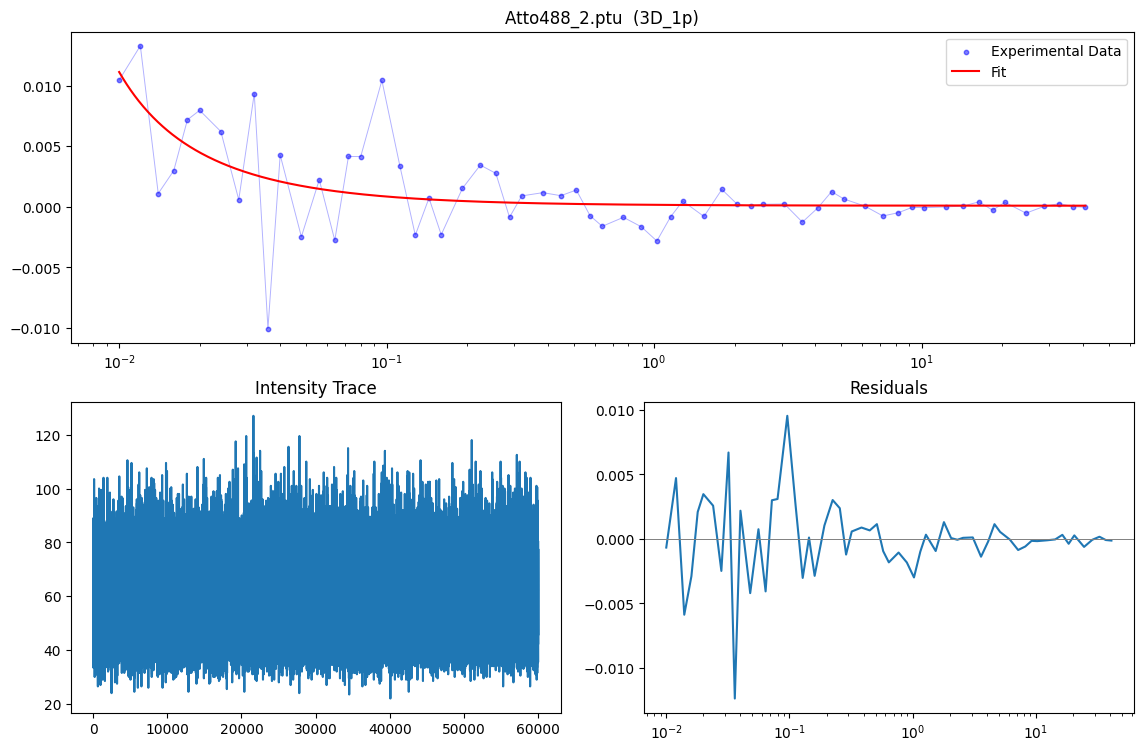

In [12]:
root = tk.Tk()
app = DataAnalysisApp(root)
root.mainloop()